# Previsão de Churn - Serviço de Cartão de Crédito
Neste projeto, o objetivo é construir um modelo de **Machine Learning** capaz de prever a probabilidade de um cliente cancelar (entrar em *churn*) o serviço de cartão de crédito de um banco. Trata-se de um problema de **Classificação Supervisionada**, onde a variável alvo (*target*) é `1` se o cliente cancelou e `0` caso contrário.

O desenvolvimento deste modelo segue as etapas fundamentais do framework **CRISP-DM**:

1. **Entendimento do Negócio:** Definição do problema e dos objetivos.
2. **Compreensão dos Dados:** Coleta e visão geral das variáveis disponíveis.
3. **Preparação dos Dados:** Divisão em conjuntos de treino e teste, limpeza e pré-processamento.
4. **Análise Exploratória de Dados (EDA):** Extração de *insights* e entendimento do comportamento do cliente.
5. **Engenharia de Features:** Criação de novas variáveis para melhorar o poder preditivo.
6. **Modelagem:** Treinamento, comparação, seleção de *features* e otimização de hiperparâmetros.
7. **Avaliação:** Teste do modelo e interpretação dos resultados.
8. **Deploy:** Implantação do modelo em ambiente de produção.

> **Foco deste Notebook:** Realizar as etapas de **Preparação de Dados, Modelagem e Avaliação** (etapas 3, 5, 6 e 7 do pipeline acima). O principal objetivo é construir um modelo preciso que calcule a probabilidade de *churn*, além de preparar o *pipeline* de dados.

### Importando as bibliotecas

In [1]:
# Data manipulation and visualization.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Modelling
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
import optuna
import shap
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
shap.initjs()

# Filter warnings.
import warnings
warnings.filterwarnings('ignore')

# Utils
from src.utils.visualization import *
from src.utils.modelling import *

## **3. Leitura dos Dados**

In [2]:
train = pd.read_csv('../data/processed/train.csv')
test = pd.read_csv('../data/processed/test.csv')

In [3]:
train.head()

,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio,churn_flag
0,36,0,0,Unknown,Married,Less than $40K,Blue,24,4,3,2,2570.0,2230,340.0,0.686,1755,42,0.448,0.868,0
1,44,1,3,High School,Single,$60K - $80K,Silver,36,5,2,3,25276.0,0,25276.0,0.849,2282,38,0.583,0.000,1
2,46,1,2,High School,Married,$80K - $120K,Blue,30,6,3,1,11670.0,915,10755.0,0.892,4277,89,0.854,0.078,0
3,36,0,2,Graduate,Married,Less than $40K,Blue,24,3,1,3,3124.0,1593,1531.0,0.869,1652,41,0.367,0.510,0
4,50,1,1,Graduate,Single,$120K +,Blue,40,4,2,3,34516.0,1185,33331.0,0.725,3874,72,0.714,0.034,0


- Vou renomear as colunas para um formato padrão a fim de facilitar a manipulação dos dados. *Attrition_Flag* será renomeada para *churn_flag* para fins de interpretação. Além disso, irei convertê-la para um formato binário (`1` para churn, `0` caso contrário), para que seja adequada aos algoritmos de *Machine Learning*.

### Dividir os dados em conjuntos de treino e teste
- Antes de tudo, vou dividir os dados em conjuntos de treino e teste.
- O conjunto de teste deve ser composto de dados que o modelo nunca viu antes.
- Essa divisão evitará o vazamento de dados (*data leakage*), que ocorre quando informações do conjunto de teste ou de dados futuros vazam inadvertidamente para o processo de treinamento, levando a uma estimativa de desempenho excessivamente otimista, o que compromete a capacidade do modelo de generalizar para dados novos e invisíveis.
- Uma boa prática para proteger o modelo contra vazamento de dados é realizar o `fit_transform` nos dados de treinamento e apenas o `transform` nos dados de teste ao aplicar as etapas de pré-processamento após a divisão.
- Especifiquei `stratify=y` para que a função `train_test_split` garanta que o processo de divisão mantenha a mesma porcentagem de cada classe da variável alvo em ambos os conjuntos de treinamento e teste. Isso é particularmente útil ao lidar com conjuntos de dados desbalanceados, que é o caso, pois há mais clientes existentes do que os que cancelaram.

In [4]:
X_train = train.drop(columns=['churn_flag'])
y_train = train['churn_flag'].copy()

X_test = test.drop(columns=['churn_flag'])
y_test = test['churn_flag'].copy()


In [5]:
print(f'Train predictor dataset shape: {X_train.shape}.')
print(f'Train target dataset shape: {y_train.shape}.')
print(f'Test predictor dataset shape: {X_test.shape}.')
print(f'Test target dataset shape: {y_test.shape}.')

Train predictor dataset shape: (8101, 19).
Train target dataset shape: (8101,).
Test predictor dataset shape: (2026, 19).
Test target dataset shape: (2026,).


In [6]:
print(f'Train target proportion: ')
print(f'{y_train.value_counts(normalize=True)}')
print(f'\nTest target proportion: ')
print(f'{y_test.value_counts(normalize=True)}')

Train target proportion: 
churn_flag
0    0.839279
1    0.160721
Name: proportion, dtype: float64

Test target proportion: 
churn_flag
0    0.839585
1    0.160415
Name: proportion, dtype: float64


As proporções das classes da variável alvo foram preservadas.

## **5. Engenharia de Features, limpeza de dados e pré-processamento**
A fim de treinar algoritmos de *machine learning*, é necessário aplicar algumas transformações aos dados. Não há valores ausentes nos dados e os *outliers* não representam informações inconsistentes. Portanto, apenas aplicarei técnicas de pré-processamento, mencionadas abaixo.

Considerando que modelos lineares e baseados em árvores requerem técnicas de pré-processamento distintas, construirei dois pré-processadores:
- Para o pré-processador de modelos baseados em árvores, não aplicarei nenhuma técnica de pré-processamento às variáveis numéricas porque esses modelos não requerem escalonamento (*scaling*). Para as variáveis categóricas com relacionamentos ordinais (nível de escolaridade, faixa de renda e categoria do cartão), aplicarei a codificação ordinal (*ordinal encoding*), para preservar essa característica. Para a variável categórica restante (estado civil), aplicarei a codificação de alvo (*target encoding*) porque a codificação *one-hot* pode ser prejudicial para modelos baseados em árvores devido à representação esparsa e ao aumento da dimensionalidade. O *one-hot encoding* será aplicado apenas ao gênero, porque ele será convertido em uma única variável binária, não aumentando a dimensionalidade.
- Para os modelos lineares, aplicarei escalonamento padrão (*standard scaling*) às variáveis numéricas porque esses algoritmos utilizam cálculos baseados em distância ou algoritmos de otimização como o gradiente descendente, sendo sensíveis à escala. Para as variáveis categóricas, aplicarei o *one-hot encoding*. Isso porque os modelos lineares apresentam a premissa de linearidade e tiram proveito dessa técnica porque, ao criar *dummies* para cada categoria, os tratamos individualmente, atribuindo um peso distinto e garantindo que a linearidade esteja presente (1 quando a categoria está presente, 0 caso contrário). Uma observação importante é que, como estou focando no poder preditivo, não dedicarei muito tempo procurando por problemas de multicolinearidade ou discretizando variáveis contínuas numéricas (tarefas para melhorar o desempenho de modelos lineares, atendendo às suas premissas) porque minha ideia é usar um modelo robusto como o LightGBM. Testarei os modelos lineares apenas para ver se o desempenho deles supera este poderoso algoritmo de aumento de gradiente (*gradient boosting*). Se for o caso, eu os usaria, balanceando o custo computacional.

Engenharia de features:
- A fim de extrair a máxima informação das variáveis disponíveis, farei engenharia de *features*, que já está incorporada no pré-processador.
- Vou criar as seguintes *features*:
    - Features de razão: *products_per_dependent* (total_relationship_count / dependent_count), *trans_amt_per_dependent* (total_trans_amt / dependent_count), *trans_ct_per_dependent* (total_trans_ct / dependent_count), *trans_amt_per_products* (total_trans_amt / total_relationship_count), *trans_ct_per_products* (total_trans_ct / total_relationship_count), *avg_trans_amt* (total_trans_amt / total_trans_ct), *credit_util_rate* (total_revolving_bal / credit_limit), *proportion_inactive_months* (months_inactive_12_mon / months_on_book), *products_per_tenure* (total_relationship_count / months_on_book), *products_per_contacts* (total_relationship_count / contacts_count_12_mon), *dependents_per_contacts* (dependent_count / contacts_count_12_mon), *trans_ct_per_contacts* (total_trans_ct / contacts_count_12_mon), *products_per_inactivity* (total_relationship_count / months_inactive_12_mon), *dependents_per_inactivity* (dependent_count / months_inactive_12_mon), *trans_ct_per_inactivity* (total_trans_ct / months_inactive_12_mon), *trans_amt_per_credit_limit* (total_trans_amt / credit_limit), *age_per_tenure* (customer_age / months_on_book), *trans_ct_per_tenure* (total_trans_ct / months_on_book), *trans_amt_per_tenure* (total_trans_amt / months_on_book).
    - Features de soma: *total_spending* (total_trans_amt + total_revolving_bal), *education_income_levels* (education_level + income_category, após transformação ordinal), *inactivity_contacts* (contacts_count_12_mon + months_inactive_12_mon).
    - Como são variáveis numéricas, todas serão escalonadas (*scaled*) para seguir para a etapa de comparação de modelos (validação cruzada K-fold estratificada).
    - Eventualmente, outras variáveis serão adicionadas. As *features* acima já conseguem capturar relações e padrões ocultos. Além disso, fazem sentido no contexto de negócios. Isso é algo importante a se levar em consideração ao realizar a engenharia de *features*.
    
Considerações sobre algumas nuances observadas na EDA:
- Manterei a categoria 'Unknown' nas colunas *income_category*, *marital_status* e *education_level* como uma categoria separada, pois vi na EDA que essa categoria apresenta discriminação entre churners e não churners. Na variável *marital_status*, ela apresenta a taxa de *churn* mais alta. Portanto, não farei nenhuma imputação, pois introduziria viés e perda de informações.
- Manterei a variável *card_category* nos dados porque, embora seja muito desbalanceada, observou-se que as categorias Gold e Silver apresentam taxas de *churn* um pouco maiores. Como pretendo usar modelos robustos focados em poder preditivo, manterei a variável e deixarei um método de seleção de *features* removê-la, caso seja inútil.
- Vou descartar a variável *Avg_Open_To_Buy* porque observei que ela tem correlação positiva perfeita com *Credit_Limit*, o que torna a informação redundante.
- Vou descartar *CLIENTNUM* porque possui um valor único para cada registro.
- Vou descartar duas variáveis específicas (aquelas do classificador *Naive Bayes*) porque não temos acesso ao seu significado e parecem ser de vazamento de dados (*data leakage*).
- Novamente, não tratarei de problemas como multicolinearidade porque o foco é construir modelos robustos, buscando o máximo de poder preditivo.

Todo o pré-processamento mencionado acima é feito por classes de transformadores, definidas no módulo de utilidades. Isso nos permite integrar tudo em um único pipeline do `sklearn`, facilitando o deploy do modelo em ambiente de produção.

In [7]:
X_train.head()

,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,avg_open_to_buy,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio
0,36,0,0,Unknown,Married,Less than $40K,Blue,24,4,3,2,2570.0,2230,340.0,0.686,1755,42,0.448,0.868
1,44,1,3,High School,Single,$60K - $80K,Silver,36,5,2,3,25276.0,0,25276.0,0.849,2282,38,0.583,0.000
2,46,1,2,High School,Married,$80K - $120K,Blue,30,6,3,1,11670.0,915,10755.0,0.892,4277,89,0.854,0.078
3,36,0,2,Graduate,Married,Less than $40K,Blue,24,3,1,3,3124.0,1593,1531.0,0.869,1652,41,0.367,0.510
4,50,1,1,Graduate,Single,$120K +,Blue,40,4,2,3,34516.0,1185,33331.0,0.725,3874,72,0.714,0.034


Verificar variáveis numéricas.

In [8]:
numerical_features = X_train.select_dtypes('number').columns.to_list()
print(f'There are {len(numerical_features)} numerical features.')
print('They are:')
print(numerical_features)

There are 15 numerical features.
They are:
['customer_age', 'gender', 'dependent_count', 'months_on_book', 'total_relationship_count', 'months_inactive_12_mon', 'contacts_count_12_mon', 'credit_limit', 'total_revolving_bal', 'avg_open_to_buy', 'total_amt_chng_q4_q1', 'total_trans_amt', 'total_trans_ct', 'total_ct_chng_q4_q1', 'avg_utilization_ratio']


Verificar a cardinalidade das variáveis categóricas e seus valores únicos.

In [9]:
categorical_features = X_train.select_dtypes('object').columns.to_list()
print(f'There are {len(categorical_features)} categorical features.')
print('They are: ')
print(categorical_features)

There are 4 categorical features.
They are: 
['education_level', 'marital_status', 'income_category', 'card_category']


In [10]:
for feature in categorical_features:
    print(feature)
    print('-'*40)
    print(f'There are {X_train[feature].nunique()} unique values. They are: ')
    print(X_train[feature].value_counts(normalize=True))
    print()

education_level
----------------------------------------
There are 7 unique values. They are: 
education_level
Graduate         0.306382
High School      0.203679
Unknown          0.148994
Uneducated       0.146031
College          0.098259
Post-Graduate    0.052710
Doctorate        0.043945
Name: proportion, dtype: float64

marital_status
----------------------------------------
There are 4 unique values. They are: 
marital_status
Married     0.463523
Single      0.387853
Unknown     0.074682
Divorced    0.073941
Name: proportion, dtype: float64

income_category
----------------------------------------
There are 6 unique values. They are: 
income_category
Less than $40K    0.349586
$40K - $60K       0.178990
$80K - $120K      0.149241
$60K - $80K       0.140230
Unknown           0.109369
$120K +           0.072584
Name: proportion, dtype: float64

card_category
----------------------------------------
There are 4 unique values. They are: 
card_category
Blue        0.933095
Silver     

Vou criar ambos os pré-processadores abaixo, seguindo as técnicas que mencionei anteriormente.

In [11]:
# Construct the preprocessor for linear models.
one_hot_encoding_features = ['gender', 
                             'education_level', 
                             'marital_status', 
                             'income_category', 
                             'card_category']
std_scaling_features = ['customer_age', 
                        'dependent_count', 
                        'months_on_book', 
                        'total_relationship_count', 
                        'months_inactive_12_mon', 
                        'contacts_count_12_mon', 
                        'credit_limit', 
                        'total_revolving_bal', 
                        'avg_open_to_buy', 
                        'total_amt_chng_q4_q1', 
                        'total_trans_amt', 
                        'total_trans_ct', 
                        'total_ct_chng_q4_q1',
                        'products_per_dependent',
                        'trans_amt_per_dependent',
                        'products_per_dependent',
                        'trans_amt_per_dependent',
                        'trans_ct_per_dependent',
                        'trans_amt_per_products',
                        'trans_ct_per_products',
                        'avg_trans_amt',
                        'credit_util_rate',
                        'proportion_inactive_months',
                        'products_per_tenure',
                        'products_per_contacts',
                        'dependents_per_contacts',
                        'trans_ct_per_contacts',
                        'products_per_inactivity',
                        'dependents_per_inactivity',
                        'trans_ct_per_inactivity',
                        'trans_amt_per_credit_limit',
                        'age_per_tenure',
                        'trans_ct_per_tenure',
                        'trans_amt_per_tenure',
                        'total_spending',
                        'inactivity_contacts',
                        'education_income_levels']

to_drop_features = ['naive_bayes_classifier_attrition_flag_card_category_contacts_count_12_mon_dependent_count_education_level_months_inactive_12_mon_1', 
                    'naive_bayes_classifier_attrition_flag_card_category_contacts_count_12_mon_dependent_count_education_level_months_inactive_12_mon_2',
                    'clientnum',
                    'avg_open_to_buy']

linear_preprocessor = Pipeline(
    steps=[
        ('feature_engineer', FeatureEngineer()),
        ('one_hot_encoder', OneHotFeatureEncoder(to_encode=one_hot_encoding_features)),
        ('std_scaler', StandardFeatureScaler(to_scale=std_scaling_features)),
        ('col_dropper', ColumnDropper(to_drop=to_drop_features))
    ]
)

X_train_prepared_linear = linear_preprocessor.fit_transform(X_train)
X_train_prepared_linear.shape

(8101, 55)

In [12]:
X_train_prepared_linear.head()

,avg_utilization_ratio,gender_1,education_level_Doctorate,education_level_Graduate,education_level_High School,education_level_Post-Graduate,education_level_Uneducated,education_level_Unknown,marital_status_Married,marital_status_Single,...,products_per_inactivity,dependents_per_inactivity,trans_ct_per_inactivity,trans_amt_per_credit_limit,age_per_tenure,trans_ct_per_tenure,trans_amt_per_tenure,total_spending,inactivity_contacts,education_income_levels
0,0.868,0,0,0,0,0,0,1,1,0,...,-0.485952,-1.237821,-0.880000,-0.381331,0.816497,-0.178604,-0.494497,-0.442467,0.129437,-1.477093
1,0.000,1,0,0,1,0,0,0,0,1,...,0.365249,0.264667,-0.663276,-1.013049,-0.443162,-0.943028,-0.578903,-0.922191,0.129437,0.026353
2,0.078,1,0,0,1,0,0,0,1,0,...,0.000449,-0.570049,-0.200931,-0.718602,0.967656,1.160665,0.107518,-0.102463,-0.526738,0.527502
3,0.510,0,0,1,0,0,0,0,1,0,...,0.730050,0.765496,0.290311,-0.545573,0.816497,-0.224470,-0.531703,-0.650920,-0.526738,0.026353
4,0.034,1,0,1,0,0,0,0,0,1,...,0.000449,-0.736992,0.073587,-0.989645,-0.317196,-0.123566,-0.288816,-0.139928,0.129437,2.030949


In [13]:
# Construct the preprocessor for tree-based models.
one_hot_encoding_features = ['gender']

# I will encode 'unknown' as the last one, due to its churn rate (among the first or second highest one).
ordinal_encoding_orders = {
    'education_level': ['Uneducated',
                        'High School',
                        'College',
                        'Graduate',
                        'Post-Graduate',
                        'Doctorate',
                        'Unknown'],
    'income_category': ['Less than $40K',
                        '$40K - $60K',
                        '$60K - $80K',
                        '$80K - $120K',
                        '$120K +',
                        'Unknown'],
    'card_category': ['Blue',
                      'Silver',
                      'Gold',
                      'Platinum']
}

target_encoding_features = ['marital_status']

to_drop_features = ['naive_bayes_classifier_attrition_flag_card_category_contacts_count_12_mon_dependent_count_education_level_months_inactive_12_mon_1', 
                    'naive_bayes_classifier_attrition_flag_card_category_contacts_count_12_mon_dependent_count_education_level_months_inactive_12_mon_2',
                    'clientnum',
                    'avg_open_to_buy']

tree_preprocessor = Pipeline(
    steps=[
        ('feature_engineer', FeatureEngineer()),
        ('one_hot_encoder', OneHotFeatureEncoder(to_encode=one_hot_encoding_features)),
        ('ordinal_encoder', OrdinalFeatureEncoder(to_encode=ordinal_encoding_orders)),
        ('target_encoder', TargetFeatureEncoder(to_encode=target_encoding_features)),
        ('col_dropper', ColumnDropper(to_drop=to_drop_features))
    ]
)

X_train_prepared_tree = tree_preprocessor.fit_transform(X_train, y_train)
X_train_prepared_tree.shape

(8101, 40)

In [14]:
X_train_prepared_tree.head()

,customer_age,dependent_count,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,total_amt_chng_q4_q1,total_trans_amt,...,trans_ct_per_tenure,trans_amt_per_tenure,total_spending,inactivity_contacts,education_income_levels,gender_1,education_level,income_category,card_category,marital_status
0,36,0,24,4,3,2,2570.0,2230.0,0.686,1755.0,...,1.750000,73.125000,3985,5,0,0,6,0,0,0.153397
1,44,3,36,5,2,3,25276.0,0.0,0.849,2282.0,...,1.055556,63.388889,2282,5,3,1,1,2,1,0.168998
2,46,2,30,6,3,1,11670.0,915.0,0.892,4277.0,...,2.966667,142.566666,5192,4,4,1,1,3,0,0.153397
3,36,2,24,3,1,3,3124.0,1593.0,0.869,1652.0,...,1.708333,68.833336,3245,4,3,0,3,0,0,0.153397
4,50,1,40,4,2,3,34516.0,1185.0,0.725,3874.0,...,1.800000,96.849998,5059,5,7,1,3,4,0,0.168998


## **6. Modelagem: Treinamento, Comparação, Seleção e Ajuste**
- Nesta etapa, pretendo comparar o desempenho de diferentes modelos. Para alcançar isso, usarei a validação cruzada k-fold estratificada para treinar cada um e avaliar o score ROC-AUC. A acurácia não é uma boa métrica porque o target é desbalanceado. A validação cruzada estratificada manterá a proporção do target em cada fold, lidando com esse desbalanceamento.
- A **validação cruzada k-fold** divide o conjunto de dados em K subconjuntos, usando K-1 para treinamento e um para teste de forma iterativa. Isso ajuda a estimar a capacidade de generalização de um modelo, reduzindo o risco de *overfitting*.
- Meu objetivo aqui é selecionar o melhor modelo para prosseguir para seleção de *features*, ajuste de hiperparâmetros e avaliação final. Para obter esse melhor modelo, avaliarei os maiores scores médios ROC-AUC de validação e analisarei o *bias-variance trade-off*.

In [15]:
# Define linear and tree-based models dictionaries for k-fold cross validation.
linear_models = {
                'Logistic Regression': LogisticRegression(),
                'Linear SVC': LinearSVC(),
                'KNN': KNeighborsClassifier(),
                }

tree_models = {
              'Decision Tree': DecisionTreeClassifier(),
              'Random Forest': RandomForestClassifier(),
              'LightGBM': LGBMClassifier()
              }

Logistic Regression results: 
--------------------------------------------------
Training score: 0.8148340125919845
Average validation score: 0.9428015959558291
Standard deviation: 0.005196293958667355
Training time: 0.2699 seconds

Linear SVC results: 
--------------------------------------------------
Training score: 0.813085540048471
Average validation score: 0.942389109925835
Standard deviation: 0.005037953328984032
Training time: 0.11533 seconds

KNN results: 
--------------------------------------------------
Training score: 0.8708612159238202
Average validation score: 0.9289137881952014
Standard deviation: 0.01102718807675875
Training time: 0.00593 seconds



,model,avg_val_score,train_score
0,Logistic Regression,0.942802,0.814834
1,Linear SVC,0.942389,0.813086
2,KNN,0.928914,0.870861


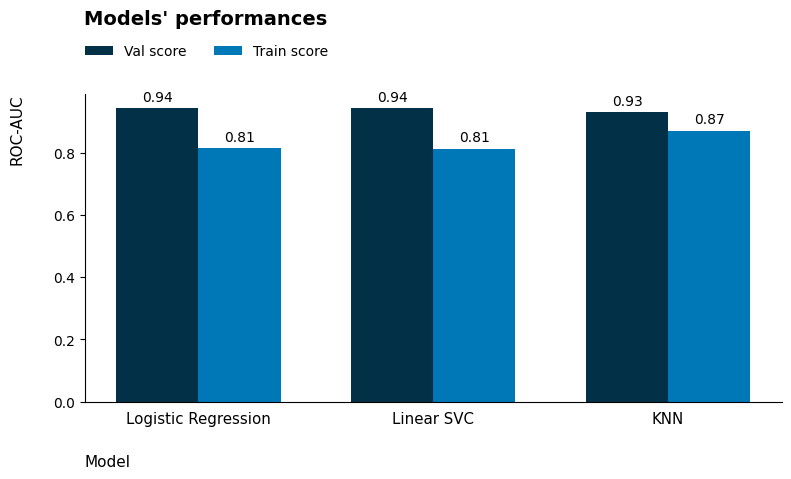

In [16]:
# K-fold cross validation for linear models.
eval_df = classification_kfold_cv(models=linear_models, 
                                  X_train=X_train_prepared_linear, 
                                  y_train=y_train, 
                                  n_folds=5)

plot_classification_kfold_cv(eval_df, bar_width=0.35, figsize=(9, 4), title_size=14, legend_x=0.175, legend_y=1.2, title_pad=50)

eval_df

Decision Tree results: 
--------------------------------------------------
Training score: 1.0
Average validation score: 0.8708172357190398
Standard deviation: 0.007303917439681949
Training time: 0.14996 seconds

Random Forest results: 
--------------------------------------------------
Training score: 0.999615975422427
Average validation score: 0.9876008579350671
Standard deviation: 0.003680444903586761
Training time: 1.47494 seconds

[LightGBM] [Info] Number of positive: 1302, number of negative: 6799
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000943 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5536
[LightGBM] [Info] Number of data points in the train set: 8101, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.160721 -> initscore=-1.652874
[LightGBM] [Info] Start training from score -1.652874
[LightGBM] [Info] Number of positive: 1041, number of negative: 5439


,model,avg_val_score,train_score
0,LightGBM,0.992292,1.000000
1,Random Forest,0.987601,0.999616
2,Decision Tree,0.870817,1.000000


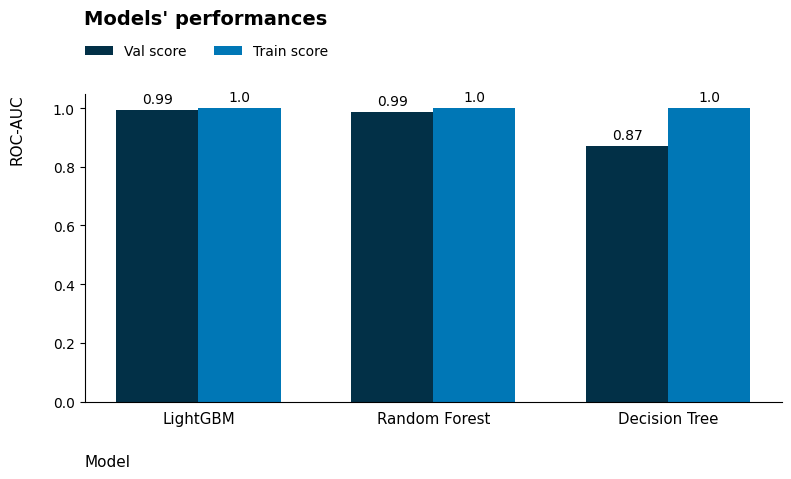

In [17]:
# K-fold cross validation for linear models.
eval_df = classification_kfold_cv(models=tree_models, 
                                  X_train=X_train_prepared_tree, 
                                  y_train=y_train, 
                                  n_folds=5)

plot_classification_kfold_cv(eval_df, bar_width=0.35, figsize=(9, 4), title_size=14, legend_x=0.175, legend_y=1.2, title_pad=50)

eval_df

Os resultados são excelentes. Seguirei com o LightGBM porque ele apresentou o maior score ROC-AUC de validação. Embora o modelo tenha um leve overfitting (ROC-AUC de 1 no treino), seu score de validação é muito próximo (0.99). O desempenho se deve à qualidade dos dados; as variáveis independentes separam claramente churners e não churners. Mesmo com esses resultados, farei a seleção de features e o ajuste de hiperparâmetros.

### Seleção de Features
- A etapa de seleção de *features* é fundamental para melhorar a generalização do modelo e torná-lo menos complexo, reduzindo o custo computacional. Como temos 40 variáveis após as transformações, simplificar o modelo sem perder desempenho é muito vantajoso.
- Utilizarei o método *Recursive Feature Elimination (RFE)* para a seleção.
- RFE é um método de seleção que remove sistematicamente as variáveis menos relevantes do modelo. Ele treina o modelo recursivamente e ranqueia a importância das variáveis, eliminando as piores até chegar ao número desejado.
- Para descobrir automaticamente o número ideal de *features*, utilizarei a classe `RFECV` do sklearn, que faz o *cross validation* K-fold para achar o melhor número.

In [18]:
# Recursively select the features with highest feature importances until the final desired number of features is obtained.
rfe = RecursiveFeatureEliminator(n_folds=5, 
                                 scoring='roc_auc',
                                 estimator=LGBMClassifier())
rfe.fit(X_train_prepared_tree, y_train)
X_train_selected = rfe.transform(X_train_prepared_tree)
X_train_selected.shape

[LightGBM] [Info] Number of positive: 1041, number of negative: 5439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001001 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5528
[LightGBM] [Info] Number of data points in the train set: 6480, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.160648 -> initscore=-1.653413
[LightGBM] [Info] Start training from score -1.653413
[LightGBM] [Info] Number of positive: 1041, number of negative: 5439
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023346 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5524
[LightGBM] [Info] Number of data points in the train set: 6480, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.160648 -> initscore=-1.653413
[LightGB

(8101, 23)

In [19]:
# Visualize the final selected features.
X_train_selected.head()

,customer_age,contacts_count_12_mon,credit_limit,total_revolving_bal,total_amt_chng_q4_q1,total_trans_amt,total_trans_ct,total_ct_chng_q4_q1,avg_utilization_ratio,trans_ct_per_dependent,...,proportion_inactive_months,products_per_tenure,trans_ct_per_contacts,products_per_inactivity,trans_ct_per_inactivity,trans_amt_per_credit_limit,age_per_tenure,trans_ct_per_tenure,trans_amt_per_tenure,total_spending
0,36.0,2.0,2570.0,2230.0,0.686,1755.0,42.0,0.448,0.868,0.000000,...,0.125000,0.166667,21.000000,1.333333,14.000000,0.682879,1.500000,1.750000,73.125000,3985.0
1,44.0,3.0,25276.0,0.0,0.849,2282.0,38.0,0.583,0.000,12.666667,...,0.055556,0.138889,12.666667,2.500000,19.000000,0.090283,1.222222,1.055556,63.388889,2282.0
2,46.0,1.0,11670.0,915.0,0.892,4277.0,89.0,0.854,0.078,44.500000,...,0.100000,0.200000,89.000000,2.000000,29.666666,0.366495,1.533333,2.966667,142.566666,5192.0
3,36.0,3.0,3124.0,1593.0,0.869,1652.0,41.0,0.367,0.510,20.500000,...,0.041667,0.125000,13.666667,3.000000,41.000000,0.528809,1.500000,1.708333,68.833336,3245.0
4,50.0,3.0,34516.0,1185.0,0.725,3874.0,72.0,0.714,0.034,72.000000,...,0.050000,0.100000,24.000000,2.000000,36.000000,0.112238,1.250000,1.800000,96.849998,5059.0


In [20]:
X_train_selected.columns.tolist()

['customer_age',
 'contacts_count_12_mon',
 'credit_limit',
 'total_revolving_bal',
 'total_amt_chng_q4_q1',
 'total_trans_amt',
 'total_trans_ct',
 'total_ct_chng_q4_q1',
 'avg_utilization_ratio',
 'trans_ct_per_dependent',
 'trans_amt_per_products',
 'trans_ct_per_products',
 'avg_trans_amt',
 'proportion_inactive_months',
 'products_per_tenure',
 'trans_ct_per_contacts',
 'products_per_inactivity',
 'trans_ct_per_inactivity',
 'trans_amt_per_credit_limit',
 'age_per_tenure',
 'trans_ct_per_tenure',
 'trans_amt_per_tenure',
 'total_spending']

- Como podemos ver, variáveis que mostraram uma clara discriminação entre churners e não churners foram mantidas. Além disso, muitas *features* que criamos na etapa de engenharia foram mantidas, demonstrando a relevância dessa etapa.
- Fomos de 40 para 25 variáveis mais importantes finais, reduzindo a complexidade de forma relevante.

### Ajuste de Hiperparâmetros (*Tuning*)
- Vou ajustar os hiperparâmetros do LightGBM usando otimização bayesiana através da biblioteca `optuna`.
- A otimização bayesiana realiza buscas inteligentes no espaço de hiperparâmetros, equilibrando o *trade-off* exploração x aproveitamento.
- *Grid search* é ineficiente porque realiza busca exaustiva. Em nosso caso seria ruim porque o dataset é relativamente grande e parâmetros interagem entre si.
- A cada iteração, treinaremos e avaliaremos no K-fold cross validation para evitar *overfitting* de busca de parâmetros.
- É importante definir o peso das classes (`scale_pos_weight`/`class_weight`) para ajudar com o desbalanceamento, aumentando o custo na perda do log quando classificados incorretamente.
- O ajuste de hiperparâmetros é um refinamento. O que melhora consideravelmente o desempenho do modelo são a engenharia de dados e a seleção de *features*.
- Como mencionei, dado o ótimo desempenho base, o ajuste não seria tão necessário, mas o farei para otimizar ao máximo.


In [21]:
def objective(trial):
    # Define the hyperparameter search space.
    params = {
        'objective': 'binary',
        'metric': 'roc_auc',
        'n_estimators': 1000,
        'verbosity': -1,
        'bagging_freq': 1,
        'class_weight': 'balanced', 
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 2, 2**10),
        'subsample': trial.suggest_float('subsample', 0.05, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.05, 1.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),
    }

    # Train the LightGBM model with the sampled hyperparameters.
    model = LGBMClassifier(**params)
    
    # Obtain average stratified k-fold cross validation roc-auc score.
    stratified_kfold = StratifiedKFold(n_splits=5, 
                                       shuffle=True, 
                                       random_state=42)
    val_scores = cross_val_score(model, 
                                 X_train_selected, 
                                 y_train, 
                                 scoring='roc_auc', 
                                 cv=stratified_kfold)
    avg_roc_auc = val_scores.mean()
    
    return avg_roc_auc

# Create an Optuna study
study = optuna.create_study(direction='maximize')

# Optimize the objective function
study.optimize(objective, n_trials=10)

# Get the best hyperparameters
best_params = study.best_params
print("Best Hyperparameters:", best_params)

[I 2026-06-21 19:32:29,481] A new study created in memory with name: no-name-a9f325d2-acb7-4d1d-9413-05091bef53b1
[I 2026-06-21 19:32:58,311] Trial 0 finished with value: 0.9921655044423044 and parameters: {'learning_rate': 0.004620506014402897, 'num_leaves': 357, 'subsample': 0.5187182254144781, 'colsample_bytree': 0.5502075734090133, 'min_data_in_leaf': 5}. Best is trial 0 with value: 0.9921655044423044.
[I 2026-06-21 19:33:07,345] Trial 1 finished with value: 0.9924883895230957 and parameters: {'learning_rate': 0.09353129847631167, 'num_leaves': 681, 'subsample': 0.9059640646785713, 'colsample_bytree': 0.6143553527830308, 'min_data_in_leaf': 5}. Best is trial 1 with value: 0.9924883895230957.
[I 2026-06-21 19:33:16,202] Trial 2 finished with value: 0.9925560219027849 and parameters: {'learning_rate': 0.07201100496256328, 'num_leaves': 529, 'subsample': 0.9294612907657339, 'colsample_bytree': 0.5365003836475416, 'min_data_in_leaf': 8}. Best is trial 2 with value: 0.9925560219027849.


Best Hyperparameters: {'learning_rate': 0.011852286484614545, 'num_leaves': 230, 'subsample': 0.654460588225852, 'colsample_bytree': 0.579569414428838, 'min_data_in_leaf': 19}


## **7. Avaliação e Teste Final do Modelo**
- Nesta etapa, avaliarei nosso modelo final com os dados de teste (simulando dados invisíveis de produção).
- Como estou lidando com um problema de classificação binária e target desbalanceado, a métrica mais apropriada é o ROC-AUC. O importante é o modelo discriminar bem entre churners e não churners.
- Como o objetivo do projeto é poder ordenar clientes por probabilidade de churn, as probabilidades de saída do modelo em si não precisam ser calibradas perfeitamente, já que focarão na discriminação e ordenação.
- Após a avaliação, interpretarei os resultados.

Obtendo o modelo final.

In [22]:
best_params = {'objective': 'binary',
               'metric': 'roc_auc',
               'n_estimators': 1000,
               'verbosity': -1,
               'bagging_freq': 1,
               'class_weight': 'balanced', 
               'learning_rate': 0.017535345166904838,
               'num_leaves': 942,
               'subsample': 0.8490611533540497,
               'colsample_bytree': 0.3775159533799494,
               'min_data_in_leaf': 90}

lgb_clf = LGBMClassifier(**best_params)
lgb_clf.fit(X_train_selected, y_train)

,boosting_type,'gbdt'
,num_leaves,942
,max_depth,-1
,learning_rate,0.017535345166904838
,n_estimators,1000
,subsample_for_bin,200000
,objective,'binary'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


Usar o pré-processador para transformar o conjunto de previsores do teste. Ao aplicar apenas transform evitamos vazamento de dados.

In [23]:
X_test_prepared = tree_preprocessor.transform(X_test)
X_test_selected = rfe.transform(X_test_prepared)
X_test_selected.shape

(2026, 23)

Prevendo.

In [24]:
y_pred = lgb_clf.predict(X_test_selected)

Obtendo as probabilidades estimadas.

In [25]:
churn_probas = lgb_clf.predict_proba(X_test_selected)[:, 1]

### Avaliando o modelo LightGBM.

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1701
           1       0.89      0.89      0.89       325

    accuracy                           0.97      2026
   macro avg       0.94      0.93      0.94      2026
weighted avg       0.97      0.97      0.97      2026

Brier Score: 0.03
Gini: 0.98
KS: 0.9


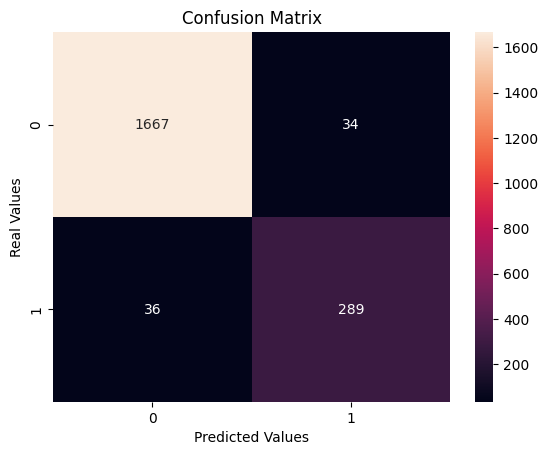

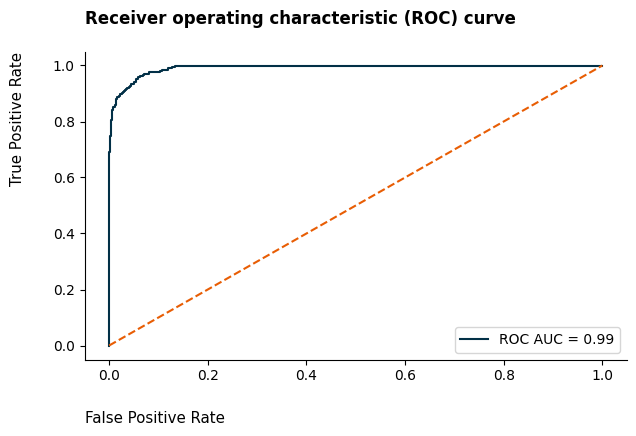

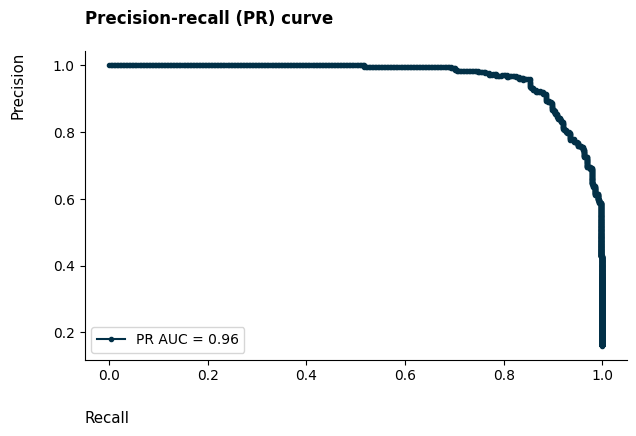

In [26]:
model_metrics = evaluate_classifier(y_test, y_pred, churn_probas, y_test)

In [27]:
model_metrics

,Metric,Value
0,Accuracy,0.965449
1,Precision,0.894737
2,Recall,0.889231
3,F1-Score,0.891975
4,ROC-AUC,0.991507
5,KS,0.900761
6,Gini,0.983015
7,PR-AUC,0.964940
8,Brier,0.026340


Os resultados do modelo são excelentes!

<b>Recall (0.89):</b> O modelo identifica corretamente 89% dos churners. Em termos práticos, observando a matriz de confusão, ele previu com precisão 290 de 325 clientes que cancelaram.<br>
<b>Precisão (0.90):</b> De todos os clientes previstos como churn, 90% deles são realmente churners. Em termos práticos, considerando a matriz de confusão, de 324 clientes previstos como churn, 290 deles são de fato churners.<br>
<b>ROC-AUC (0.99):</b> Com um score ROC-AUC de 0.99, o modelo demonstra uma capacidade excepcional de diferenciar entre clientes que cancelaram e clientes existentes. Na prática, se escolhermos aleatoriamente um cliente que cancelou e um cliente que não cancelou, em 99% das vezes o modelo estimará uma probabilidade maior de churn para o cliente que de fato cancelou.
- Este desempenho excepcional não se deve a vazamento de dados (*data leakage*), uma vez que todas as variáveis incluídas estão presentes no momento da previsão e a divisão foi feita antes de tudo. Deve-se à qualidade dos dados; as variáveis independentes separam claramente os churners dos não churners.
- Finalmente, como as pontuações de treino, teste e validação são semelhantes, a capacidade de generalização do modelo é confiável.

- Analisar a distribuição das probabilidades previstas por churn.

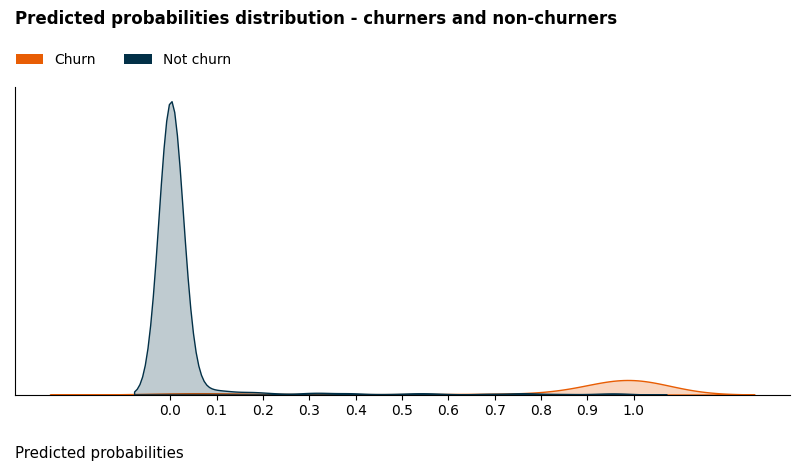

In [28]:
plot_probability_distributions(y_test, churn_probas)

- É possível observar que há uma separação clara entre as distribuições das probabilidades previstas para churners e não churners. Excelente!

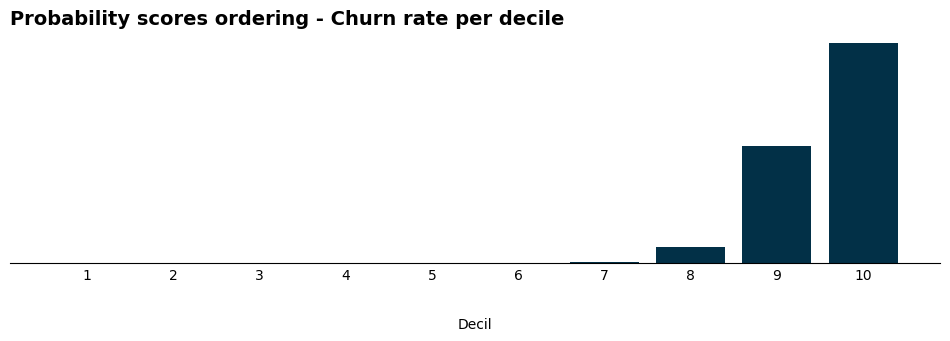

In [29]:
probability_scores_ordering(y_test, churn_probas)

- A ordenação dos scores de probabilidade também é excelente. Todos os churners caem entre o 7º e o 10º decis.

### Interpretar os resultados do modelo com valores SHAP
- Para interpretar os resultados do LightGBM, vou analisar os valores SHAP.
- O SHAP é uma biblioteca que permite a interpretação dos resultados de algoritmos de machine learning.
- Com ela, podemos entender o impacto de cada variável (*feature*) na previsão individual de um modelo. f(x) = E(f(x)) + SHAP.
- Basicamente, o valor SHAP de uma variável (o quanto ela impacta uma previsão individual) é a soma ponderada das contribuições marginais considerando todas as coalizões de variáveis possíveis. 
- Uma coalizão de variáveis é um grupo de variáveis, e seu valor é a previsão individual do modelo usando apenas aquelas variáveis.
- A contribuição marginal de uma variável é a diferença entre o valor previsto para uma coalizão de variáveis com e sem ela.
- Somamos as contribuições marginais para todas as combinações possíveis com e sem uma variável.
- Os pesos são baseados na probabilidade da variável para a qual estamos calculando o valor SHAP estar naquela combinação.

In [30]:
# Initialize the SHAP explainer with the final model.
explainer = shap.Explainer(lgb_clf)

# Compute shap values.
shap_values = explainer(X_test_selected)

In [31]:
# Assess the shape.
np.shape(shap_values.values)

(2026, 23)

In [32]:
# Assess some true labels.
y_test.reset_index(drop=True).sample(10, random_state=42)

1284    0
982     0
1542    1
593     0
1292    1
781     0
1576    0
367     0
1782    0
1788    0
Name: churn_flag, dtype: int64

- Temos 25 variáveis. Para cada uma, temos um valor SHAP correspondente para cada observação.
- Para classificação binária, interpretamos os resultados em termos de log-odds. Nos gráficos a seguir, E(f(X)) representa a previsão média de log-odds. Log-odds é basicamente o logaritmo das chances (*odds*), a razão entre a probabilidade do evento ocorrer e a probabilidade do evento não ocorrer. O logaritmo é usado para converter as chances para uma escala linear. Valores SHAP positivos aumentam as log-odds e, consequentemente, a probabilidade de churn, e vice-versa.
- Para obter a probabilidade de churn a partir das log-odds, basta passar pela função logística, definida como $$ \text{sigmoid}(x) = \frac{1}{1 + e^{-\ln\left(\frac{p}{1-p}\right)}} $$\n
- Através do gráfico de cascata (*waterfall plot*), vamos visualizar a contribuição de cada variável na previsão para uma instância positiva (churner) e negativa (não churner).\n

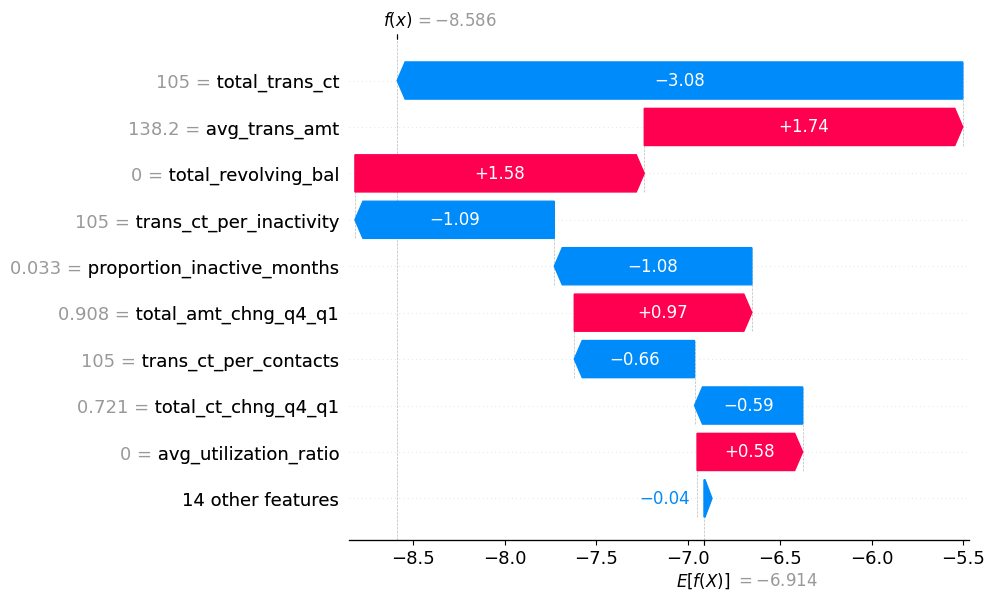

In [33]:
shap.plots.waterfall(shap_values[1])

- Este cliente não cancelou o serviço (Não Churner). A probabilidade estimada de churn para ele através da função logística é muito próxima de zero.
- É possível ver que o número de transações (nos últimos 12 meses), que é igual a 105 neste caso, reduziu as log-odds de churn em 3.07. Em contraste, o saldo rotativo total, que é zero, aumentou as log-odds em 1.41. Isso faz todo o sentido, pois vimos que quanto maior o número de transações, menor o risco de churn, e muitos churners estavam concentrados em valores nulos de saldo rotativo total e taxa média de utilização.
- Veja como as variáveis que criamos na etapa de engenharia de *features* impactaram negativa ou positivamente as log-odds de churn, por exemplo em *proportion_inactive_months* e *trans_ct_per_inactivity*.

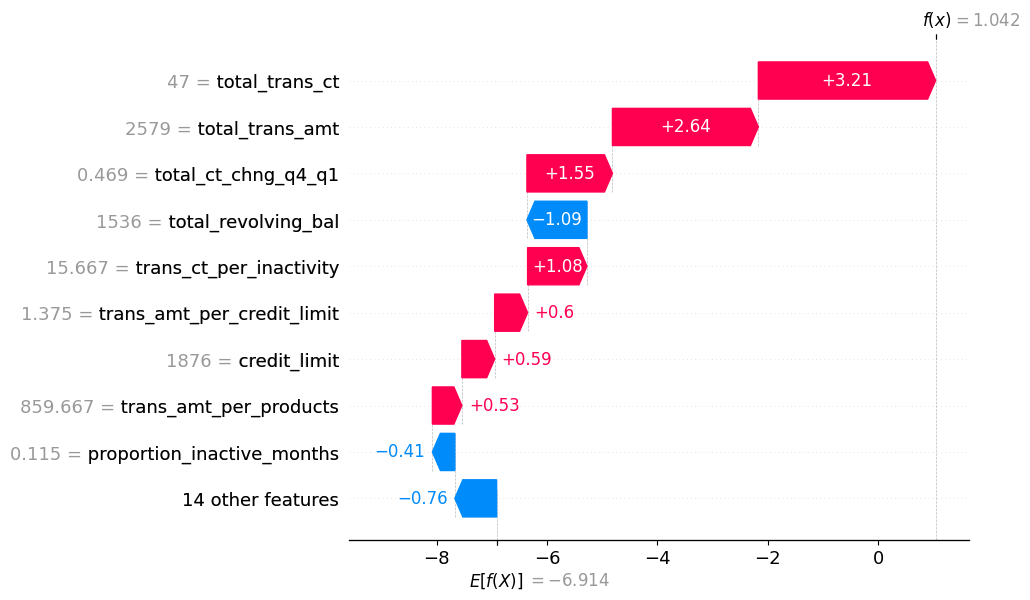

In [34]:
shap.plots.waterfall(shap_values[1542])

- Este cliente cancelou o serviço (Churner). A probabilidade estimada de churn para ele através da função logística é de cerca de 72%.
- É possível observar que, novamente, o número de transações (nos últimos 12 meses) aumentou as log-odds de churn em 3.19, o que faz total sentido, como mencionado anteriormente.

- Agora, através do gráfico de barras, observaremos quais variáveis são as mais importantes. Neste gráfico, temos o valor SHAP absoluto médio para cada variável, indicando quais contribuem mais (positivamente ou negativamente) para as previsões do modelo.

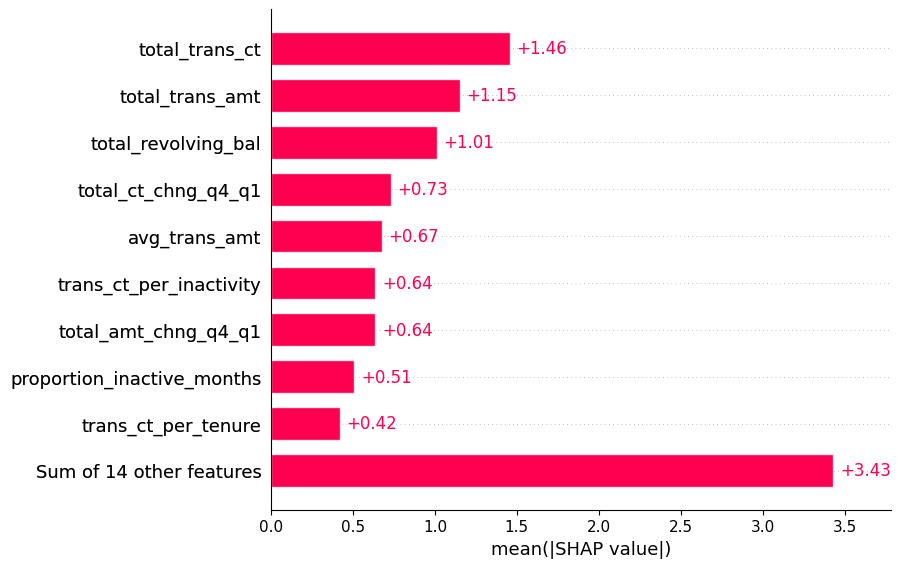

In [35]:
shap.plots.bar(shap_values)

- Como esperado, o número e o valor das transações nos últimos 12 meses são as variáveis mais importantes. Isso faz total sentido, e vimos na Análise Exploratória de Dados (EDA) que essas variáveis apresentaram uma clara discriminação entre churners e não churners. Além disso, as variáveis que criamos na etapa de engenharia de *features* apareceram como parte das mais importantes, ilustrando a importância dessa tarefa para melhorar o desempenho de um modelo de *Machine Learning*. É o caso de *trans_ct_per_inactivity* e *avg_trans_amt*, por exemplo.

- Agora, através do gráfico de dispersão (*beeswarm plot*), podemos observar a relação entre as variáveis e a previsão do modelo.

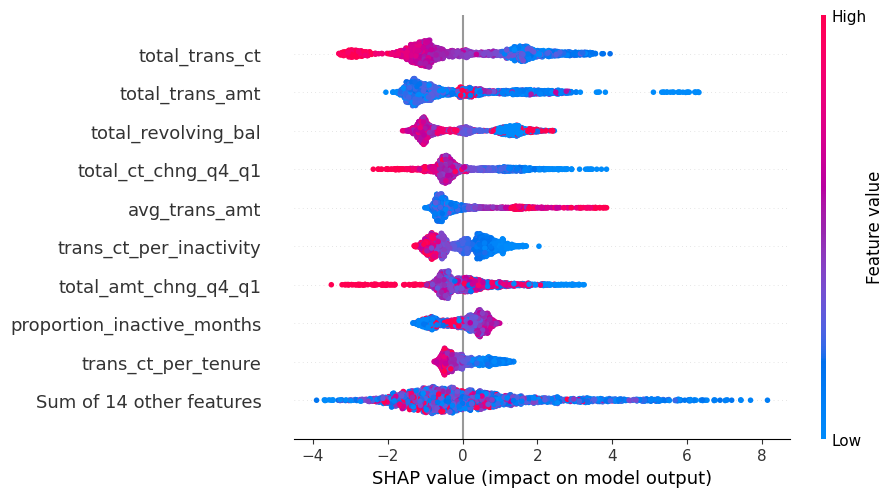

In [36]:
shap.plots.beeswarm(shap_values)

- É notável que valores mais baixos da contagem de transações nos últimos 12 meses têm um impacto positivo nas log-odds de churn e, consequentemente, na probabilidade de churn, enquanto valores mais altos têm um impacto negativo.
- Surpreendentemente, valores mais altos da quantidade média de transação tendem a refletir um impacto positivo nas log-odds de churn, e consequentemente, na probabilidade de churn, enquanto valores mais baixos tendem a ter um impacto negativo.

### Resultados Financeiros
- Expressarei o desempenho do modelo em termos de resultados financeiros para o banco, a fim de mostrar que o projeto vale a pena. Farei isso analisando a matriz de confusão e nossos dados atuais.
- Não tenho acesso a dados específicos para obter o ganho financeiro exato. No entanto, uma fonte comum de receita para empresas de cartão de crédito é a cobrança de juros sobre o saldo devedor, conhecido como saldo rotativo total. Assim, assumirei que a taxa do banco é de 18% (um valor comum) e calcularei o ganho financeiro com isso.
- Considerando isso, a fim de estimar o ganho financeiro proporcionado pelo modelo, levarei em conta os seguintes custos e benefícios:
    1. Custo de retenção por cliente (falso positivo):
        - Esse custo se aplica aos clientes que não iriam cancelar, mas foram classificados incorretamente como churners pelo modelo, levando o banco a incorrer em despesas para retê-los. Especificamente, para reter o cliente, oferecerei um desconto na taxa, reduzindo-a de 18% para 10%, resultando em uma perda de receita devido a esse desconto de 8%.
    2. Perda de receita por churner (falso negativo):
        - Esse custo surge quando os clientes que realmente vão cancelar não são corretamente identificados pelo modelo, levando o banco a perder tanto esses clientes quanto a receita associada. Esse custo abrangerá a taxa inteira (18%) aplicada aos saldos devedores.
    3. Ganho financeiro com a retenção de um cliente previsto corretamente como churner (verdadeiro positivo):
        - Esse ganho ocorre quando o modelo prevê com precisão um churner, permitindo-nos retê-lo junto com a receita que ele gera, aplicando a taxa de 10% sobre os saldos rotativos totais como nossa estratégia de retenção.

Obter um dataset para os resultados financeiros.

In [37]:
financial_results = pd.concat([X_test, y_test], axis=1)[['total_revolving_bal', 'churn_flag']]
financial_results['predicted'] = y_pred

Obter datasets separados para estimativa de custos e ganhos com falsos positivos, falsos negativos e verdadeiros positivos.

In [38]:
fp_data = financial_results.loc[(financial_results['churn_flag'] == 0) & (financial_results['predicted'] == 1)]
fn_data = financial_results.loc[(financial_results['churn_flag'] == 1) & (financial_results['predicted'] == 0)]
tp_data = financial_results.loc[(financial_results['churn_flag'] == 1) & (financial_results['predicted'] == 1)]

Estimar os custos e o ganho.

In [39]:
fp_data['fp_cost'] = fp_data['total_revolving_bal']*1.18 - fp_data['total_revolving_bal']*1.10
fn_data['fn_cost'] = fn_data['total_revolving_bal']*1.18
tp_data['tp_gain'] = tp_data['total_revolving_bal']*1.10

Finalmente, o resultado financeiro proporcionado pelo modelo será a diferença entre o ganho e os custos.

In [40]:
financial_gain = tp_data['tp_gain'].sum() - fp_data['fp_cost'].sum() - fn_data['total_revolving_bal'].sum()
print(f'The model provides a financial gain of: ${financial_gain:.1f}')

The model provides a financial gain of: $165960.3


O nosso modelo produz um resultado financeiro estimado de aproximadamente $171.477. O valor real dependerá da gestão do banco ao implementar estratégias de retenção para clientes baseadas nas probabilidades previstas de churn. Por exemplo, se o banco deseja ser mais conservador, reduzindo despesas associadas a falsos positivos, pode focar em clientes com probabilidades de churn mais altas, alterando assim o ganho potencial. No entanto, para propósitos de estimativa e fundamentação, confirmamos que o projeto vale a pena.

## **9. Conclusões**
- Neste projeto, construí um classificador LightGBM para prever a probabilidade de cancelamento (churn) de clientes em um serviço de cartão de crédito de um banco. O objetivo do projeto foi construir um modelo capaz de prever com precisão a probabilidade de um cliente cancelar, descobrir os fatores de churn dentro das variáveis disponíveis e oferecer planos de ação para minimizar o problema. Ao fazer isso, a empresa pode planejar estratégias de retenção, mantendo uma receita saudável. Adquirir novos clientes é mais caro do que manter os atuais.
- O problema de negócios está resolvido agora. O modelo é capaz de prever corretamente 89% dos churners, com um AUC de 0.99 e uma capacidade excepcional de discriminar entre churners e não churners! Isso indica que, se escolhermos aleatoriamente um churner e um não churner, em 99% do tempo o modelo estimará uma probabilidade maior de churn para o cliente que de fato cancelou. Além disso, foi possível descobrir os principais fatores de churn durante a etapa de Análise Exploratória e fornecer sugestões para o banco com relação aos padrões de cancelamento.
- A fim de lidar com o target desbalanceado, as estratégias utilizadas foram: *hold-out* estratificado, validação cruzada K-fold, e o hiperparâmetro *class_weight*. O foco foi na simulação de um caso real de ciência de dados.
- Os resultados do modelo foram interpretados e são coerentes! Ao olhar para o SHAP, foi possível avaliar as *features* com o maior poder preditivo para a análise e como elas impactam o resultado do modelo. Na etapa de EDA, as variáveis com maior potencial já haviam sido identificadas, reforçando que os resultados do modelo fazem sentido.
- O projeto vale a pena. Ele fornece um resultado financeiro básico estimado em cerca de $171.477. O resultado concreto dependerá das taxas cobradas pelo banco e de sua gestão ao implementar estratégias de retenção. No entanto, o ganho financeiro estimado fundamenta a sua viabilidade.
- O próximo passo é implantar o modelo (deploy).